## **Customer Segmentation**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv('Customer Segmentation Dataset.csv')

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
print("Shape of dataset:", df.shape)

Shape of dataset: (200, 5)


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [5]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [6]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [7]:
df.duplicated().sum()

np.int64(0)

# **Exploratory Data Analysis**

**Gender Distribution**

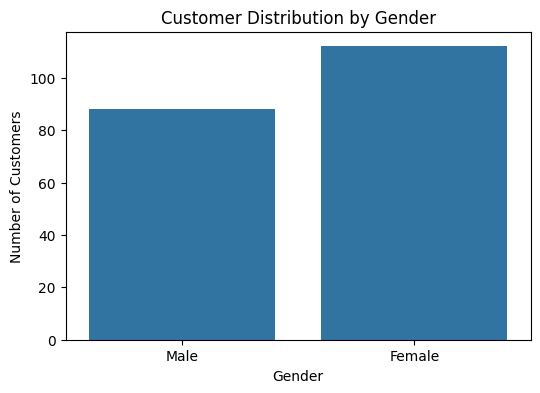

In [8]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x='Gender')

plt.title('Customer Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')

plt.show()

Age **Distribution**

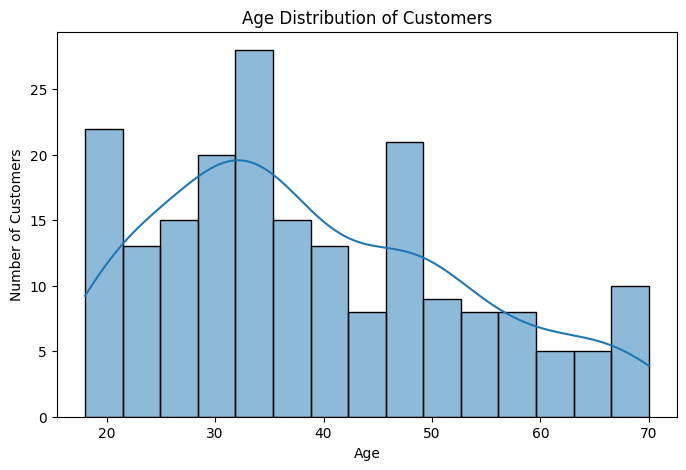

In [9]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x='Age', bins=15, kde=True)

plt.title('Age Distribution of Customers')
plt.xlabel('Age')
plt.ylabel('Number of Customers')

plt.show()

**Annual Income Distribution**

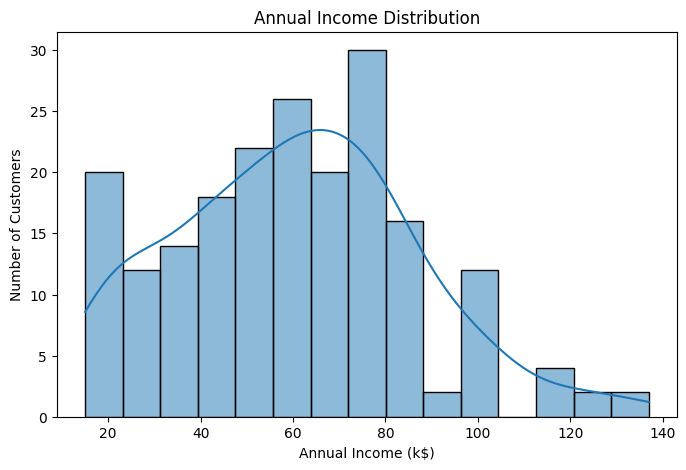

In [10]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x='Annual Income (k$)', bins=15, kde=True)

plt.title('Annual Income Distribution')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Number of Customers')

plt.show()

**Spending Score Distribution**

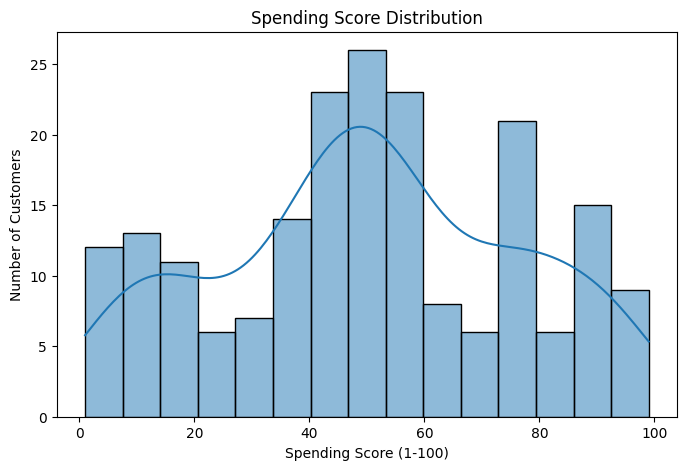

In [11]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x='Spending Score (1-100)', bins=15, kde=True)

plt.title('Spending Score Distribution')
plt.xlabel('Spending Score (1-100)')
plt.ylabel('Number of Customers')

plt.show()

**Income vs Spending Score**

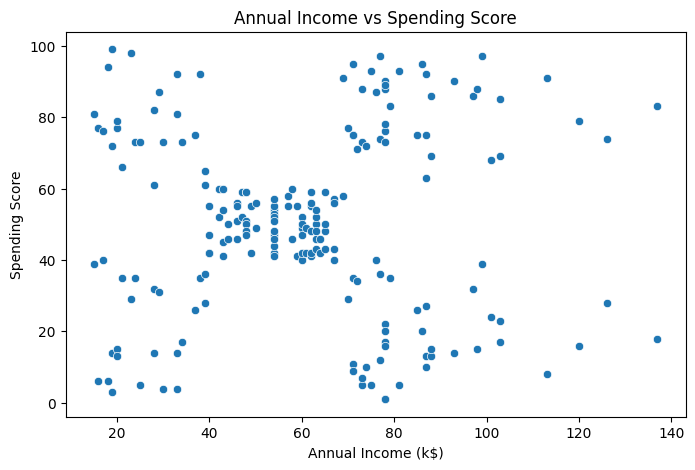

In [12]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)'
)

plt.title('Annual Income vs Spending Score')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score')

plt.show()

# **Customer Segmentation using K-Means Clustering**

**Select Features for Clustering**

In [13]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


**Find the Best Number of Clusters**

In [14]:
from sklearn.cluster import KMeans

In [15]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

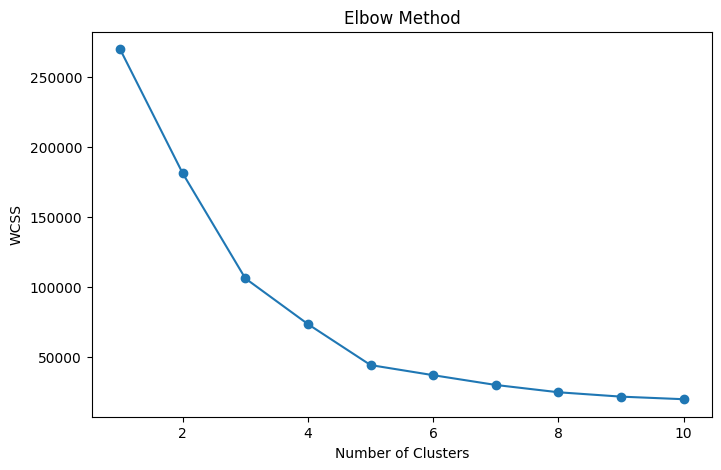

In [16]:
plt.figure(figsize=(8, 5))

plt.plot(range(1, 11), wcss, marker='o')

plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')

plt.show()

# **Apply K-Means Clustering**

In [17]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)

df['Cluster'] = kmeans.fit_predict(X)

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


**Visualize the Customer Segments**

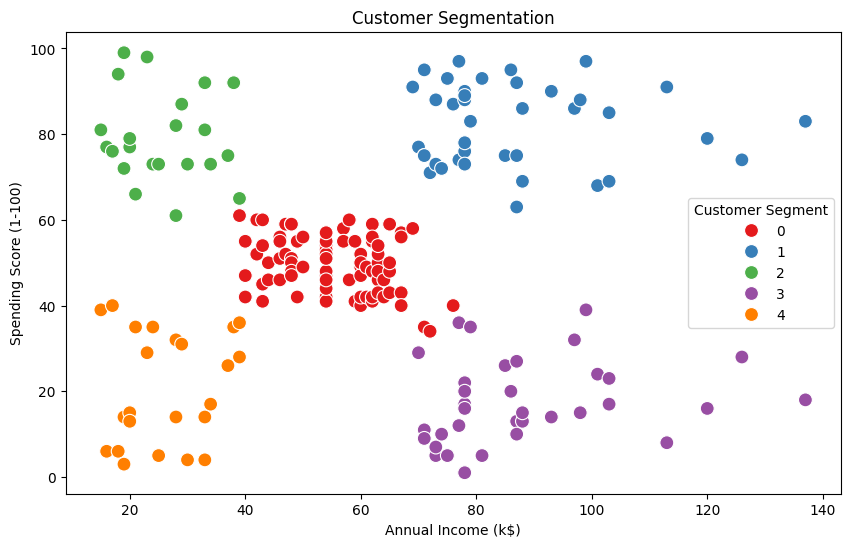

In [18]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    palette='Set1',
    s=100
)

plt.title('Customer Segmentation')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(title='Customer Segment')

plt.show()

**Analyze Each Customer Segment**

In [19]:
cluster_summary = df.groupby('Cluster').agg({
    'Age': 'mean',
    'Annual Income (k$)': 'mean',
    'Spending Score (1-100)': 'mean'
}).round(2)

cluster_summary

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,42.72,55.30,49.52
1,32.69,86.54,82.13
2,25.27,25.73,79.36
3,41.11,88.20,17.11
4,45.22,26.30,20.91


**Count Customers in Each Segment**

In [20]:
df['Cluster'].value_counts().sort_index()

,count
Cluster,
0,81
1,39
2,22
3,35
4,23


**Better Summary Table**

In [21]:
cluster_summary = df.groupby('Cluster').agg(
    Customers=('CustomerID', 'count'),
    Average_Age=('Age', 'mean'),
    Average_Income=('Annual Income (k$)', 'mean'),
    Average_Spending=('Spending Score (1-100)', 'mean')
).round(2)

cluster_summary

,Customers,Average_Age,Average_Income,Average_Spending
Cluster,,,,
0,81,42.72,55.30,49.52
1,39,32.69,86.54,82.13
2,22,25.27,25.73,79.36
3,35,41.11,88.20,17.11
4,23,45.22,26.30,20.91


**Segment Summary Graph**

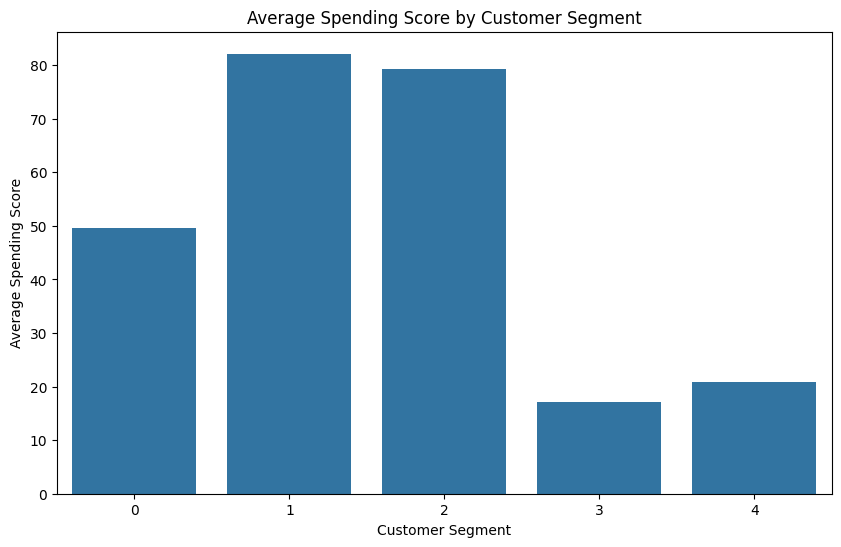

In [22]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=cluster_summary.reset_index(),
    x='Cluster',
    y='Average_Spending'
)

plt.title('Average Spending Score by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Average Spending Score')

plt.show()

**Customer Segment Profile**

In [23]:
segment_profile = cluster_summary.copy()

segment_profile['Segment_Name'] = [
    'Regular Customers',
    'High-Value Customers',
    'Young High-Spending Customers',
    'High-Income Low-Spending Customers',
    'Low-Income Low-Spending Customers'
]

segment_profile

,Customers,Average_Age,Average_Income,Average_Spending,Segment_Name
Cluster,,,,,
0,81,42.72,55.30,49.52,Regular Customers
1,39,32.69,86.54,82.13,High-Value Customers
2,22,25.27,25.73,79.36,Young High-Spending Customers
3,35,41.11,88.20,17.11,High-Income Low-Spending Customers
4,23,45.22,26.30,20.91,Low-Income Low-Spending Customers
